In [19]:
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import yfinance as yf
from datetime import datetime, timedelta, timezone
from scipy.stats import norm
warnings.filterwarnings('ignore')

In [20]:
stock_name = 'KOTAKBANK'

In [21]:
def black_scholes(S, K, T, r, sigma, option_type='call'):
    """
    S : underlying price
    K : strike price
    T : time to expiration (in days)
    r : risk-free interest rate
    sigma : volatility (annualized)
    option_type : 'call' or 'put'
    """

    # Convert T from days to years
    T /= 365
    # Protect against divide by zero
    if T == 0 or sigma == 0:
        return max(0.0, S-K) if option_type=='call' else max(0.0, K-S)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type.lower() == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:  # put
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    return price

In [22]:
# Download OHLC data from yfinance
ticker = f'{stock_name}.NS'
interval = '1d'
years = 18
days_per_chunk = 700
end_date = datetime.now()
start_date = end_date - timedelta(days=years * 365)

# Initialize
all_data = []

# Loop over chunks
while start_date < end_date:
    chunk_end = min(start_date + timedelta(days=days_per_chunk), end_date)
    print(f'Fetching data from {start_date.date()} to {chunk_end.date()}...')
    
    data = yf.download(
        ticker,
        start=start_date.strftime('%Y-%m-%d'),
        end=chunk_end.strftime('%Y-%m-%d'),
        interval=interval,
        progress=False,
        auto_adjust=False
    )

    if not data.empty:
        all_data.append(data)
    else:
        print(f'Empty data: {start_date}, {chunk_end}')

    # Move to next chunk
    start_date = chunk_end

# Combine all chunks
df = pd.concat(all_data)
# Remove duplicate timestamps if any
df = df[~df.index.duplicated(keep='first')]

# Display the result
df = df.droplevel(level='Ticker', axis=1)
df.index.name = 'Timestamp'
df.head()

Fetching data from 2008-07-01 to 2010-06-01...
Fetching data from 2010-06-01 to 2012-05-01...
Fetching data from 2012-05-01 to 2014-04-01...
Fetching data from 2014-04-01 to 2016-03-01...
Fetching data from 2016-03-01 to 2018-01-30...
Fetching data from 2018-01-30 to 2019-12-31...
Fetching data from 2019-12-31 to 2021-11-30...
Fetching data from 2021-11-30 to 2023-10-31...
Fetching data from 2023-10-31 to 2025-09-30...
Fetching data from 2025-09-30 to 2026-06-27...


Price,Adj Close,Close,High,Low,Open,Volume
Timestamp,,,,,,
2008-07-01,21.894440,22.227501,23.445000,21.787500,22.575001,34128620
2008-07-02,23.726566,24.087500,24.950001,21.750000,22.350000,36427900
2008-07-03,21.182764,21.504999,24.100000,20.927500,23.750000,53415560
2008-07-04,22.209644,22.547501,22.844999,21.049999,21.495001,73944340
2008-07-07,22.872061,23.219999,24.235001,22.799999,22.852501,30198240


In [23]:
repo_df = pd.read_csv('./repo_rate.csv', index_col=0, parse_dates=True)
repo_df.index.rename('Timestamp', inplace=True)
repo_df.head()

,Repo rate
Timestamp,
2025-04-01,5.50
2024-04-01,6.96
2023-04-01,7.24
2022-04-01,7.32
2021-04-01,6.28


In [24]:
# Integrate repo rate data and ffill
final_df = pd.merge(df, repo_df, left_index=True, right_index=True, how='outer')
final_df.rename(columns={'Repo rate': 'rfr'}, inplace=True)
final_df['rfr'].ffill(inplace=True)
final_df.dropna(inplace=True)
final_df['rfr'] = final_df['rfr']/100

# Calculate 60 days rolling standard deviation
final_df['ret'] = final_df['Close'].pct_change()
final_df['vol'] = final_df['ret'].rolling(window=45).std()
final_df['vol'] = final_df['vol']*np.sqrt(252)
final_df.dropna(inplace=True)

final_df.tail()

,Adj Close,Close,High,Low,Open,Volume,rfr,ret,vol
Timestamp,,,,,,,,,
2026-06-19,399.250000,399.250000,403.549988,398.000000,402.500000,17504009.0,0.055,-0.009182,0.190860
2026-06-22,402.149994,402.149994,403.100006,398.750000,399.250000,7158956.0,0.055,0.007264,0.189012
2026-06-23,401.649994,401.649994,405.000000,398.000000,398.000000,10077909.0,0.055,-0.001243,0.188466
2026-06-24,405.950012,405.950012,407.950012,400.200012,401.649994,11768059.0,0.055,0.010706,0.186190
2026-06-25,409.000000,409.000000,413.799988,407.200012,409.500000,16587414.0,0.055,0.007513,0.180967


In [25]:
# Since the expiry day for stock future and options at
# Indian exchanges is at last Tuesday of every month
# We will close our positions 1 day prior to expiry day
# Get list of expiry days (last monday of the month)
# Mark the last monday of each month as a new month
weekday_const = {
    'monday': 0,
    'tuesday': 1,
    'wednesday': 2,
    'thursday': 3,
    'friday': 4,
    'saturday': 5,
    'sunday': 6,
}
def last_weekdays(start_date, end_date, weekday):
    """
    Return a list of dates representing the last weekday 
    of each month between start_date and end_date (inclusive).
    """
    results = []
    weekday_no = weekday_const[weekday.lower()]
    # Normalize to first day of the start month
    year, month = start_date.year, start_date.month

    while True:
        # Last day of the current month
        last_day = calendar.monthrange(year, month)[1]
        last_date = datetime(year, month, last_day)

        # Find the last weekday
        # weekday(): Monday=0 ... Sunday=6, Thursday=3
        offset = (last_date.weekday() - weekday_no) % 7
        last_weekday = last_date - timedelta(days=offset)

        # Add if within the range
        if start_date <= last_weekday <= end_date:
            results.append(last_weekday)

        # Move to next month
        if (year, month) == (end_date.year, end_date.month):
            break

        month += 1
        if month == 13:
            month = 1
            year += 1

    return results

In [26]:
start_dt, end_dt = df.index[0].to_pydatetime(), df.index[-1].to_pydatetime()
end_dt += pd.Timedelta(days=30)
expiry_days = last_weekdays(start_dt, end_dt, 'tuesday')
expiry_days.sort()

In [27]:
def get_atm_strike(stock_price):
    """
    ATM strike price is decided by the price band
    in which the underlying price of a stock belongs.
    These price bands and their respective adjustments
    are purely decided based on observations
    """
    price_1_percent = stock_price/100
    if price_1_percent >= 100:
        factor = 100
    elif price_1_percent >= 50 and price_1_percent < 100:
        factor = 50
    elif price_1_percent >= 20 and price_1_percent < 50:
        factor = 20
    elif price_1_percent >= 10 and price_1_percent < 20:
        factor = 10
    elif price_1_percent >= 3 and price_1_percent < 10:
        factor = 5
    elif price_1_percent >= 2 and price_1_percent < 3:
        factor = 2
    else:
        factor = 1
    atm_strike = stock_price - stock_price%factor
    return atm_strike

In [28]:
def get_expiry_date(current_date):
    for expiry_date in expiry_days:
        if expiry_date >= current_date:
            return expiry_date

In [29]:
# Strategy book maintains buy sell entries of only the strategy level
# position
strategy_book = []

# Tradebook maintains all the buy sell activities of the strategy.
# One row in the tradebook list will have position opening details
# and position closing details both
tradebook = []

# In tradelog we will update daily UPL and RPL of open positions
# This log will be used to calculate the performance of the strategy
trade_log = []

trades = None
prev_log = None
strategy_trade = None
for index in range(final_df.shape[0]):
    row = final_df.iloc[index, :]
    current_date = row.name
    log = {}

    # if trade is None
    if trades is None:
        # Open short straddle position
        
        # Define the ATM strike
        current_price = row['Close']
        atm_strike = get_atm_strike(current_price)
        
        # Get the upcoming expiry date
        expiry_date = get_expiry_date(current_date)

        # Calculate the TTE
        tte = (expiry_date - current_date).days
        
        # Calculate the call and put option price
        atm_call_price = black_scholes(current_price, atm_strike, tte, row['rfr'], row['vol'], 'call')
        atm_put_price = black_scholes(current_price, atm_strike, tte, row['rfr'], row['vol'], 'put')
        
        # Decide the OTM strike
        otm_strike_diff = atm_call_price + atm_put_price
        otm_call_strike = get_atm_strike(atm_strike + otm_strike_diff)
        otm_put_strike = get_atm_strike(atm_strike - otm_strike_diff)

        # Buy OTM options
        otm_call_price = black_scholes(current_price, otm_call_strike, tte, row['rfr'], row['vol'], 'call')
        otm_put_price = black_scholes(current_price, otm_put_strike, tte, row['rfr'], row['vol'], 'put')

        # Update the trade variable
        trades = {
            'atm_call': {'option_type': 'atm_call', 'strike': atm_strike, 'expiry': expiry_date, 'entry_price': atm_call_price, 'entry_date': current_date, 'position': -1, 'margin': atm_call_price*3},
            'atm_put': {'option_type': 'atm_put', 'strike': atm_strike, 'expiry': expiry_date, 'entry_price': atm_put_price, 'entry_date': current_date, 'position': -1, 'margin': atm_put_price*3},
            'otm_call': {'option_type': 'otm_call', 'strike': otm_call_strike, 'expiry': expiry_date, 'entry_price': otm_call_price, 'entry_date': current_date, 'position': 1, 'margin': otm_call_price*3},
            'otm_put': {'option_type': 'otm_put', 'strike': otm_put_strike, 'expiry': expiry_date, 'entry_price': otm_put_price, 'entry_date': current_date, 'position': 1, 'margin': otm_put_price*3},
        }

        strategy_trade = {
            'entry_date': current_date,
            'expiry_date': expiry_date,
            'entry_price': atm_call_price + atm_put_price - otm_call_price - otm_put_price,
            # 'entry_price': atm_call_price + atm_put_price,
            'pos': -1,
            'margin': (atm_call_price + atm_put_price - otm_call_price - otm_put_price)*3,
            'entry_u_price': current_price
        }

        # Calculate the straddle position value
        log['price'] = atm_call_price + atm_put_price - otm_call_price - otm_put_price
        log['pos'] = -1
        log['date'] = current_date
        log['expiry_date'] = expiry_date
        log['margin'] = log['price']*3
        log['ret'] = 0
    # else
    else:
        # is it an expiry day
        expiry_date = strategy_trade['expiry_date']
        tte = (expiry_date - current_date).days
        if tte <= 1:
            # Square off the position
            current_price = row['Close']
            
            # Calc option prices
            atm_call_price = black_scholes(current_price, trades['atm_call']['strike'], tte, row['rfr'], row['vol'], 'call')
            atm_put_price = black_scholes(current_price, trades['atm_put']['strike'], tte, row['rfr'], row['vol'], 'put')

            otm_call_price = black_scholes(current_price, trades['otm_call']['strike'], tte, row['rfr'], row['vol'], 'call')
            otm_put_price = black_scholes(current_price, trades['otm_put']['strike'], tte, row['rfr'], row['vol'], 'put')
            
            # Update the trade variable
            trades['atm_call']['exit_price'] = atm_call_price
            trades['atm_call']['exit_date'] = current_date
            trades['atm_put']['exit_price'] = atm_put_price
            trades['atm_put']['exit_date'] = current_date
            trades['otm_call']['exit_price'] = otm_call_price
            trades['otm_call']['exit_date'] = current_date
            trades['otm_put']['exit_price'] = otm_put_price
            trades['otm_put']['exit_date'] = current_date
            
            # Update the tradebook
            for trade in trades.values():
                tradebook.append(trade)
            trades = None
            
            # Update the strategy book
            strategy_trade['exit_price'] = atm_call_price + atm_put_price - otm_call_price - otm_put_price
            # strategy_trade['exit_price'] = atm_call_price + atm_put_price
            strategy_trade['exit_date'] = current_date
            strategy_trade['exit_u_price'] = current_price
            strategy_book.append(strategy_trade)
            strategy_trade = None
            
            # Update the log data
            log['price'] = atm_call_price + atm_put_price - otm_call_price - otm_put_price
            log['pos'] = -1
            log['date'] = current_date
            log['expiry_date'] = expiry_date
            log['margin'] = prev_log['margin']
            log['ret'] = log['price']/prev_log['price'] - 1
            trade_log.append(log)
            log = {}
            prev_log = None

            # Take a new trade
            # Define the ATM strike
            current_price = row['Close']
            atm_strike = get_atm_strike(current_price)
            
            # Calculate the TTE
            future_row = final_df.iloc[index + 2, :]
            future_date = future_row.name
            expiry_date = get_expiry_date(future_date)
            tte = (expiry_date - current_date).days
            
            # Calculate the call and put option price
            atm_call_price = black_scholes(current_price, atm_strike, tte, row['rfr'], row['vol'], 'call')
            atm_put_price = black_scholes(current_price, atm_strike, tte, row['rfr'], row['vol'], 'put')
            
            # Decide the OTM strike
            otm_strike_diff = atm_call_price + atm_put_price
            otm_call_strike = get_atm_strike(atm_strike + otm_strike_diff)
            otm_put_strike = get_atm_strike(atm_strike - otm_strike_diff)

            # Buy OTM options
            otm_call_price = black_scholes(current_price, otm_call_strike, tte, row['rfr'], row['vol'], 'call')
            otm_put_price = black_scholes(current_price, otm_put_strike, tte, row['rfr'], row['vol'], 'put')

            # Update the trade variable
            trades = {
                'atm_call': {'option_type': 'atm_call', 'strike': atm_strike, 'expiry': expiry_date, 'entry_price': atm_call_price, 'entry_date': current_date, 'position': -1, 'margin': atm_call_price*3},
                'atm_put': {'option_type': 'atm_put', 'strike': atm_strike, 'expiry': expiry_date, 'entry_price': atm_put_price, 'entry_date': current_date, 'position': -1, 'margin': atm_put_price*3},
                'otm_call': {'option_type': 'otm_call', 'strike': otm_call_strike, 'expiry': expiry_date, 'entry_price': otm_call_price, 'entry_date': current_date, 'position': 1, 'margin': otm_call_price*3},
                'otm_put': {'option_type': 'otm_put', 'strike': otm_put_strike, 'expiry': expiry_date, 'entry_price': otm_put_price, 'entry_date': current_date, 'position': 1, 'margin': otm_put_price*3},
            }

            strategy_trade = {
                'entry_date': current_date,
                'expiry_date': expiry_date,
                'entry_price': atm_call_price + atm_put_price - otm_call_price - otm_put_price,
                # 'entry_price': atm_call_price + atm_put_price,
                'pos': -1,
                'margin': (atm_call_price + atm_put_price - otm_call_price - otm_put_price)*3,
                'entry_u_price': current_price
            }

            # Calculate the straddle position value
            log['price'] = atm_call_price + atm_put_price - otm_call_price - otm_put_price
            log['pos'] = -1
            log['date'] = current_date
            log['expiry_date'] = expiry_date
            log['margin'] = log['price']*3
            log['ret'] = 0
        # else
        else:
            # Log the strategy returns
            current_price = row['Close']

            # Calc option prices
            atm_call_price = black_scholes(current_price, trades['atm_call']['strike'], tte, row['rfr'], row['vol'], 'call')
            atm_put_price = black_scholes(current_price, trades['atm_put']['strike'], tte, row['rfr'], row['vol'], 'put')

            # Buy OTM options
            otm_call_price = black_scholes(current_price, trades['otm_call']['strike'], tte, row['rfr'], row['vol'], 'call')
            otm_put_price = black_scholes(current_price, trades['otm_put']['strike'], tte, row['rfr'], row['vol'], 'put')

            # Log the updated strategy value in trade_log
            log['price'] = atm_call_price + atm_put_price - otm_call_price - otm_put_price
            log['pos'] = -1
            log['date'] = current_date
            log['expiry_date'] = expiry_date
            log['margin'] = prev_log['margin']
            log['ret'] = log['price']/prev_log['price'] - 1
    trade_log.append(log)
    prev_log = log

In [30]:
strategy_df = pd.DataFrame(strategy_book)
strategy_df['st_ret'] = 100*strategy_df['pos']*(strategy_df['exit_price']-strategy_df['entry_price'])/strategy_df['margin']
strategy_df['u_ret'] = 100*(strategy_df['exit_u_price']/strategy_df['entry_u_price'] - 1)
strategy_df.head()

,entry_date,expiry_date,entry_price,pos,margin,entry_u_price,exit_price,exit_date,exit_u_price,st_ret,u_ret
0,2008-09-04,2008-09-30,3.727362,-1,11.182087,31.977501,4.039820,2008-09-29,26.9475,-2.794268,-15.729812
1,2008-09-29,2008-10-28,2.921092,-1,8.763275,26.947500,4.998947,2008-10-27,14.8600,-23.710943,-44.855740
2,2008-10-27,2008-11-25,1.720883,-1,5.162648,14.860000,1.472523,2008-11-24,15.6550,4.810703,5.349933
3,2008-11-24,2008-12-30,2.467709,-1,7.403128,15.655000,2.401927,2008-12-29,17.5975,0.888574,12.408177
4,2008-12-29,2009-01-27,2.442917,-1,7.328752,17.597500,4.000000,2009-01-27,13.0000,-21.246220,-26.125870


In [31]:
trade_log_df = pd.DataFrame(trade_log)
trade_log_df['adj_ret'] = trade_log_df['pos']*trade_log_df['ret']/trade['margin']
trade_log_df['cum_ret'] = (1 + trade_log_df['adj_ret']).cumprod()
trade_log_df.set_index('date', inplace=True)
trade_log_df.head()

,price,pos,expiry_date,margin,ret,adj_ret,cum_ret
date,,,,,,,
2008-09-04,3.727362,-1,2008-09-30,11.182087,0.000000,-0.000000,1.000000
2008-09-05,3.773382,-1,2008-09-30,11.182087,0.012347,-0.001653,0.998347
2008-09-08,3.511617,-1,2008-09-30,11.182087,-0.069371,0.009287,1.007619
2008-09-09,3.465071,-1,2008-09-30,11.182087,-0.013255,0.001774,1.009407
2008-09-10,3.431799,-1,2008-09-30,11.182087,-0.009602,0.001285,1.010704


In [32]:
final_df['cum_ret'] = (1 + final_df['ret']).cumprod()
final_df.tail()

,Adj Close,Close,High,Low,Open,Volume,rfr,ret,vol,cum_ret
Timestamp,,,,,,,,,,
2026-06-19,399.250000,399.250000,403.549988,398.000000,402.500000,17504009.0,0.055,-0.009182,0.190860,12.270458
2026-06-22,402.149994,402.149994,403.100006,398.750000,399.250000,7158956.0,0.055,0.007264,0.189012,12.359585
2026-06-23,401.649994,401.649994,405.000000,398.000000,398.000000,10077909.0,0.055,-0.001243,0.188466,12.344219
2026-06-24,405.950012,405.950012,407.950012,400.200012,401.649994,11768059.0,0.055,0.010706,0.186190,12.476374
2026-06-25,409.000000,409.000000,413.799988,407.200012,409.500000,16587414.0,0.055,0.007513,0.180967,12.570112


In [33]:
win_trades = len(strategy_df[strategy_df['st_ret'] > 0])
loss_trades = len(strategy_df[strategy_df['st_ret'] <= 0])
total_trades = len(strategy_df)
win_ratio = round(100*win_trades/total_trades, 2)
print(f'Total trades: {total_trades}')
print(f'Win trades: {win_trades}')
print(f'Loss trades: {loss_trades}')
print(f'Win ratio: {win_ratio}%')

avg_win = strategy_df[strategy_df['st_ret'] > 0]['st_ret'].mean()
avg_loss = strategy_df[strategy_df['st_ret'] <= 0]['st_ret'].mean()
ev = (win_trades*avg_win+loss_trades*avg_loss)/total_trades
print(f'Avg win: {round(avg_win, 2)}%')
print(f'Avg loss: {round(avg_loss, 2)}%')
print(f'Expected value: {round(ev, 2)}%')

Total trades: 213
Win trades: 100
Loss trades: 113
Win ratio: 46.95%
Avg win: 14.66%
Avg loss: -10.84%
Expected value: 1.13%


In [34]:
start_date = final_df.index[0]
end_date = final_df.index[-1]
period = (end_date - start_date).days/365

# Buy and hold returns
bnh_returns = (final_df['cum_ret'].iloc[-1] - 1)
strategy_returns = (trade_log_df['cum_ret'].iloc[-1] - 1)

print(f'Buy and hold total returns for period of {round(period)} years: {round(bnh_returns*100)}%')
print(f'Strategy total returns for period of {round(period)} years: {round(strategy_returns*100)}%')

# Show returns in CAGR
bnh_CAGR_ret = bnh_returns**(1/period) - 1
strategy_CAGR_ret = strategy_returns**(1/period) - 1

print(f'Buy and hold CAGR returns: {round(bnh_CAGR_ret*100, 2)}%')
print(f'Strategy CAGR returns: {round(strategy_CAGR_ret*100, 2)}%')

Buy and hold total returns for period of 18 years: 1157%
Strategy total returns for period of 18 years: 149%
Buy and hold CAGR returns: 14.73%
Strategy CAGR returns: 2.27%


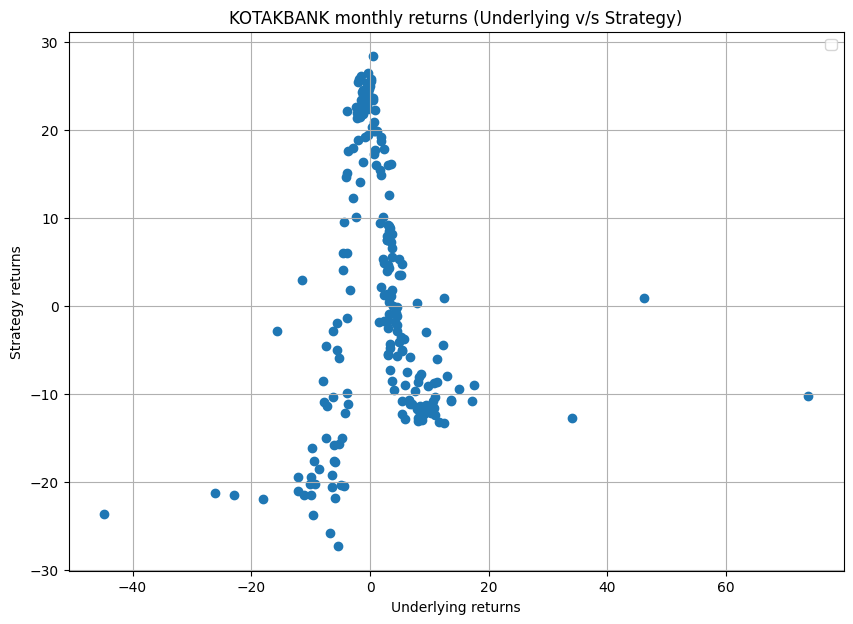

In [35]:
plt.figure(figsize=(10, 7))

plt.scatter(strategy_df['u_ret'], strategy_df['st_ret'])

plt.grid()
plt.xlabel('Underlying returns')
plt.ylabel('Strategy returns')
plt.title(f'{stock_name} monthly returns (Underlying v/s Strategy)')

plt.legend()
plt.show()

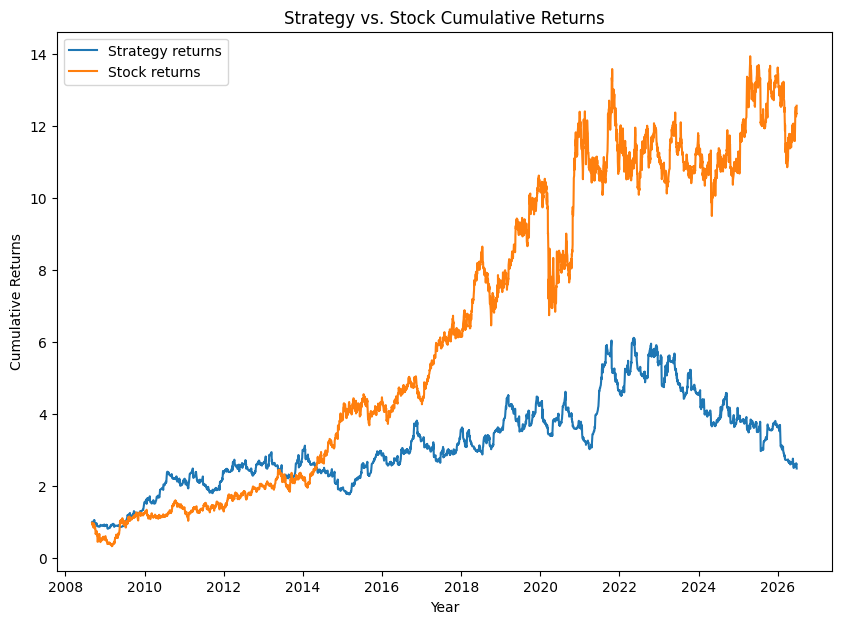

In [36]:
plt.figure(figsize=(10, 7))

plt.plot(trade_log_df['cum_ret'], label='Strategy returns')
plt.plot(final_df['cum_ret'], label='Stock returns')

plt.xlabel("Year")
plt.ylabel("Cumulative Returns")
plt.title("Strategy vs. Stock Cumulative Returns")

plt.legend()
plt.show()